In [1]:

# import autoreject


In [1]:
import os
import numpy as np
import pandas as pd
import glob

import mne
import autoreject
import seaborn


In [2]:
scaling = 9e-5

In [3]:
# Listing folder and files
data_path = "/Users/alicerueda/Documents/TI EEG/"
print(data_path)
eeg_files = glob.glob(data_path+"*MMN*.bdf")
eeg_files



/Users/alicerueda/Documents/TI EEG/


['/Users/alicerueda/Documents/TI EEG/TI-MDD_TI00_V1_Post_MMN_20240216.bdf',
 '/Users/alicerueda/Documents/TI EEG/TI-MDD_TI00_V1_Pre_MMN_20240216.bdf']

In [7]:
eeg_file = eeg_files[1]
eeg_file

'/Users/alicerueda/Documents/TI EEG/TI-MDD_TI00_V1_Pre_MMN_20240216.bdf'

In [ ]:
# Loading data (raw) and set to the proper channels
raw = mne.io.read_raw_bdf(eeg_file, preload=True)
biosemi32_montage = mne.channels.make_standard_montage('biosemi32')
# ask John about moving the electrodes F7/8 to AF7/8. Which montage (32 or 64) we should use for analysis?
raw.set_montage(biosemi32_montage, on_missing='ignore')

print(raw.info["bads"])
raw = raw.drop_channels(['AF1', 'AF2']

# raw.ch_names

Extracting EDF parameters from /Users/alicerueda/Documents/TI EEG/TI-MDD_TI00_V1_Pre_MMN_20240216.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 720895  =      0.000 ...   176.000 secs...


<RawEDF | TI-MDD_TI00_V1_Pre_MMN_20240216.bdf, 48 x 720896 (176.0 s), ~264.1 MB, data loaded>

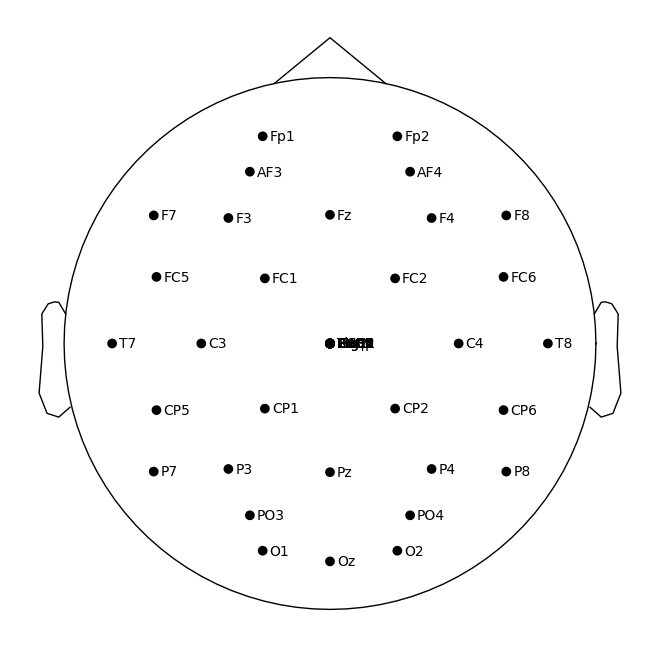

In [9]:
fig = raw.plot_sensors(show_names=True)


In [10]:
# use average of mastoid channels as reference
raw.set_eeg_reference(ref_channels=['EXG1', 'EXG2'])
#raw.set_eeg_reference(ref_channels='average')

# Set EOG channels to EXG3, EXG4, EXG5, and EXG6
eog_channels = ['EXG3', 'EXG4', 'EXG5', 'EXG6']
raw.set_channel_types({ch: 'eog' for ch in eog_channels})
raw.rename_channels({'EXG3': 'HLEOG', 
                     'EXG4': 'HREOG',
                     'EXG5': 'VLEOG',
                     'EXG6': 'VREOG'})

# ecg_channel
raw.set_channel_types({'EXG7': 'ecg'})
raw.rename_channels({'EXG7': 'ECG'})

#raw.ch_names[34:37] = ['HLEOG', 'HREOG', 'VLEOG', 'VREOG']
raw.ch_names


EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.


['Fp1',
 'AF3',
 'F7',
 'F3',
 'FC1',
 'FC5',
 'T7',
 'C3',
 'CP1',
 'CP5',
 'P7',
 'P3',
 'Pz',
 'PO3',
 'O1',
 'Oz',
 'O2',
 'PO4',
 'P4',
 'P8',
 'CP6',
 'CP2',
 'C4',
 'T8',
 'FC6',
 'FC2',
 'F4',
 'F8',
 'AF4',
 'Fp2',
 'Fz',
 'Cz',
 'EXG1',
 'EXG2',
 'HLEOG',
 'HREOG',
 'VLEOG',
 'VREOG',
 'ECG',
 'EXG8',
 'GSR1',
 'GSR2',
 'Erg1',
 'Erg2',
 'Resp',
 'Plet',
 'Temp',
 'Status']

In [11]:

# Drop not used channels
#if len(raw.ch_names)==48:
#    raw.drop_channels(['EXG1','EXG2','EXG8','GSR1','GSR2','Erg1', 'Erg2', 'Resp','Plet','Temp'])
#else:
#    raw.drop_channels(['EXG1','EXG2','EXG8'])
#
#print(raw.info)

raw.drop_channels(['EXG1','EXG2','EXG8','GSR1','GSR2','Erg1', 'Erg2', 'Resp','Plet','Temp'])


<RawEDF | TI-MDD_TI00_V1_Pre_MMN_20240216.bdf, 38 x 720896 (176.0 s), ~209.1 MB, data loaded>

Using matplotlib as 2D backend.


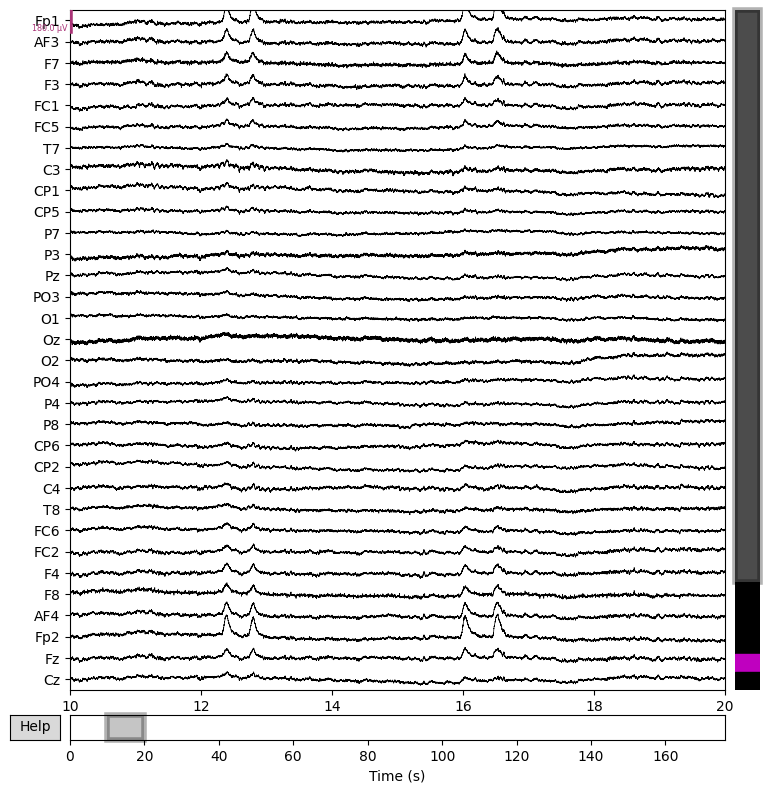

In [12]:
# PLOT

# add new reference channel (all zero)
#raw_new_ref = mne.add_reference_channels(raw, ref_channels=['EXG1', 'EXG2'])
fig = raw.plot(start = 10, duration = 10, n_channels = 32, clipping=None, scalings=dict(eeg=scaling))

In [13]:
print(raw)

n_time_samps = raw.n_times
time_secs = raw.times
ch_names = raw.ch_names
n_chan = len(ch_names)  # note: there is no raw.n_channels attribute

print(
    f"the (cropped) sample data object has {n_time_samps} time samples and "
    f"{n_chan} channels."
)

print(f"The last time sample is at {time_secs[-1]} seconds.")
print("The first few channel names are {}.".format(", ".join(ch_names[:3])))
print()  # insert a blank line in the output

# some examples of raw.info:
print("bad channels:", raw.info["bads"])  # chs marked "bad" during acquisition
print(raw.info["sfreq"], "Hz")  # sampling frequency
fs = raw.info["sfreq"]

print(raw.info["description"], "\n")  # miscellaneous acquisition info

print(raw.info)

<RawEDF | TI-MDD_TI00_V1_Pre_MMN_20240216.bdf, 38 x 720896 (176.0 s), ~209.1 MB, data loaded>
the (cropped) sample data object has 720896 time samples and 38 channels.
The last time sample is at 175.999755859375 seconds.
The first few channel names are Fp1, AF3, F7.

bad channels: []
4096.0 Hz
None 

<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, AF3, F7, F3, FC1, FC5, T7, C3, CP1, CP5, P7, P3, Pz, PO3, ...
 chs: 32 EEG, 4 EOG, 1 ECG, 1 Stimulus
 custom_ref_applied: True
 dig: 35 items (3 Cardinal, 32 EEG)
 highpass: 0.0 Hz
 lowpass: 834.0 Hz
 meas_date: 2024-02-16 11:07:02 UTC
 nchan: 38
 projs: []
 sfreq: 4096.0 Hz
>


In [14]:
# filtering
'''
for cutoff in (0.1, 0.2, 0.5):
    raw_highpass = raw.copy().filter(l_freq=cutoff, h_freq=None)
    with mne.viz.use_browser_backend("matplotlib"):
        fig = raw_highpass.plot(
            duration=60, proj=False, n_channels=len(raw.ch_names), remove_dc=False
        )
    fig.subplots_adjust(top=0.9)
    fig.suptitle(f"High-pass filtered at {cutoff} Hz", size="xx-large", weight="bold")
    
'''


'\nfor cutoff in (0.1, 0.2, 0.5):\n    raw_highpass = raw.copy().filter(l_freq=cutoff, h_freq=None)\n    with mne.viz.use_browser_backend("matplotlib"):\n        fig = raw_highpass.plot(\n            duration=60, proj=False, n_channels=len(raw.ch_names), remove_dc=False\n        )\n    fig.subplots_adjust(top=0.9)\n    fig.suptitle(f"High-pass filtered at {cutoff} Hz", size="xx-large", weight="bold")\n    \n'

In [15]:
# print(raw.time_as_index(20))   #20x512
# print(raw.time_as_index([20, 30, 40]), "\n")

# print(np.diff(raw.time_as_index([1, 2, 3])))

# Events

We do not have annotation on the events, but numberes. 
https://mne.tools/stable/auto_tutorials/intro/10_overview.html#sphx-glr-auto-tutorials-intro-10-overview-py

In [16]:
# events label extaction
event_from_labels, event_dict = mne.events_from_annotations(raw)

print(event_dict)

events = mne.find_events(raw)
print(events)

event_dict={'tone1': 1, 'tone2':2}

start_time,_ , _= events[1]

start_time = round(start_time/512)
print(start_time)

end_time,_,_ = events[len(events)-1]
end_time = round(end_time/fs)
print(end_time)

{}
Trigger channel has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
541 events found
Event IDs: [  1   2  32  64 128]
[[ 35921      0      1]
 [ 36012      0      2]
 [ 36494      0    128]
 ...
 [697961      0    128]
 [698974      0      1]
 [700373      0    128]]
70
171



# Plotting EEG signals
Ploting the first 10s after MMN start and the last 10s before MMN ends

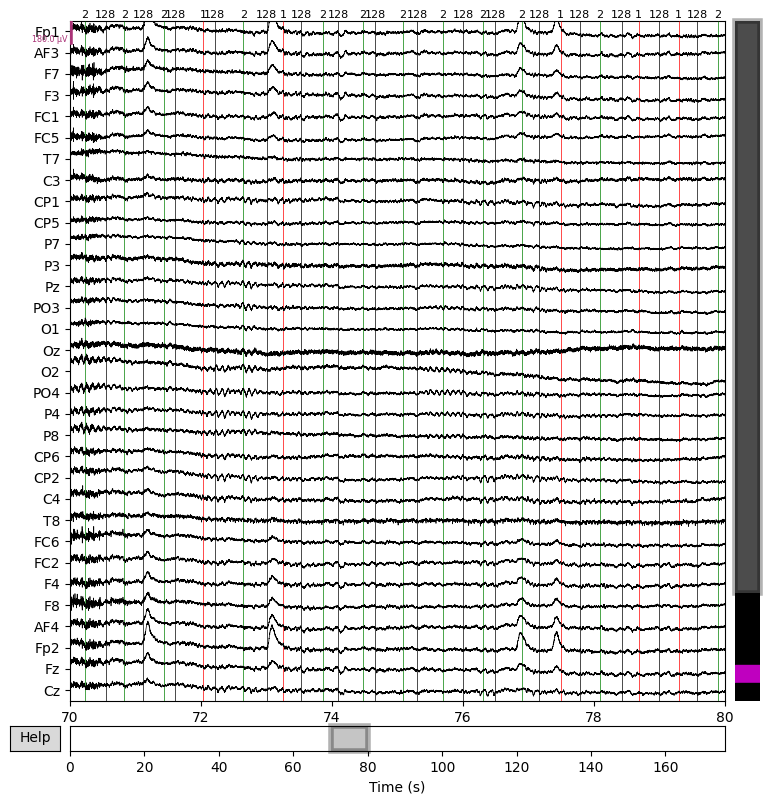

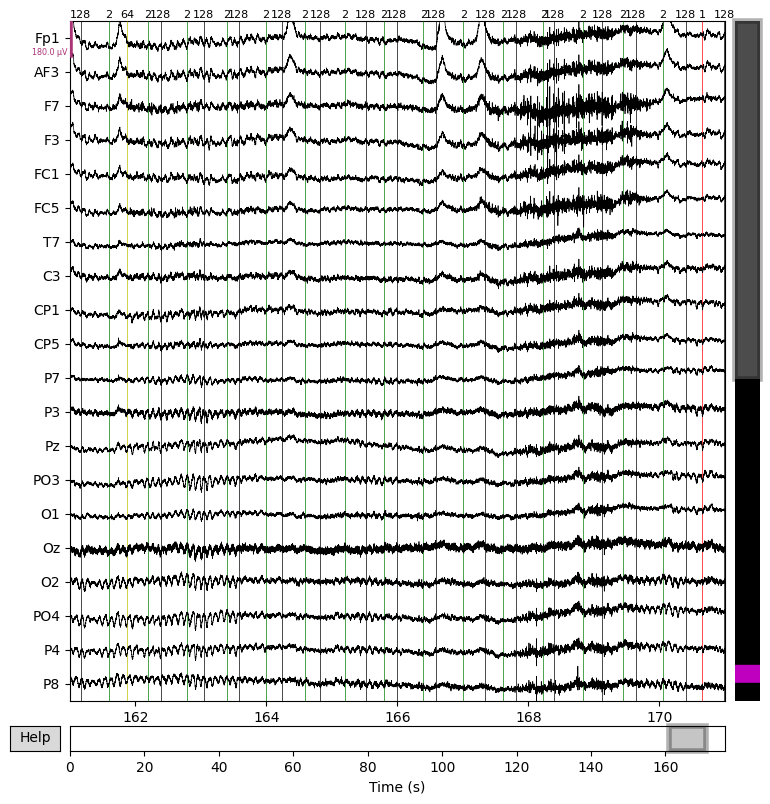

In [17]:
# Plot before croping front and back
fig =  raw.plot(events=events,start = start_time, duration = 10, n_channels=32,
                event_color={1: "r", 2: "g", 4: "b", 32: "m", 64: "y", 99: "k",128: "k",129: "k"},
                clipping=None, scalings=dict(eeg=scaling))

fig = raw.plot(events=events, start=(end_time-10), duration = 10,
               event_color={1: "r", 2: "g", 4: "b", 32: "m", 64: "y", 99: "k",128: "k",129: "k"},
               clipping=None, scalings=dict(eeg=scaling))

# Crop the EEG signals
#print(f"start time: {start_time}")
#print(f"end time: {end_time}")
#raw.crop(tmin=start_time, tmax=end_time, include_tmax=True)



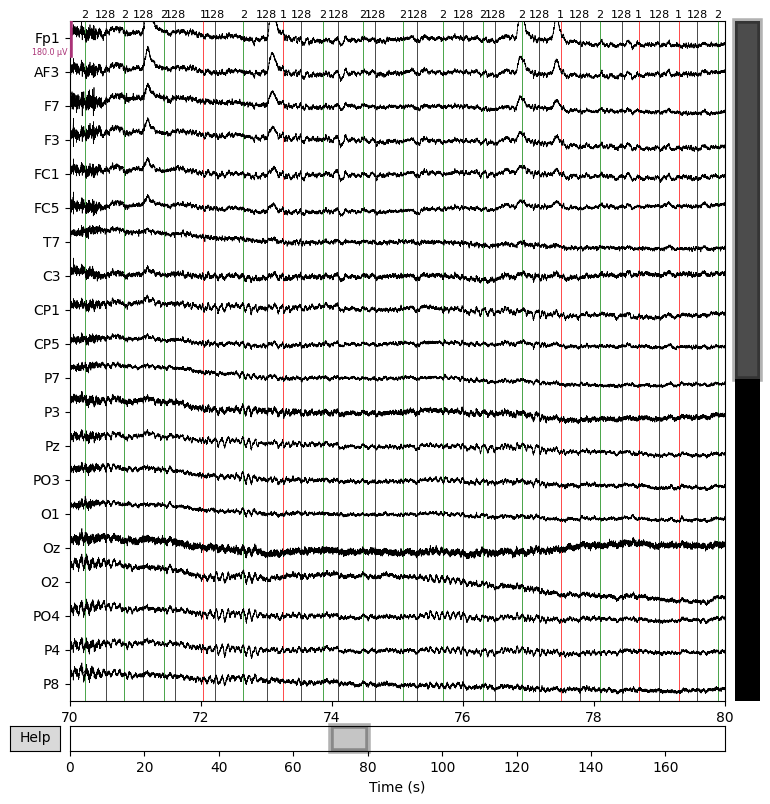

In [18]:
# PLOT

'''
event_dict = {
    "Tone1": 1,  # 1 is also start
    "Tone2": 2,
    "TriggerInst": 4,
    "VisualRight": 32,
    "VisualLeft": 64,
    "Start": 99,
    "VisualDummy":128,
    "End": 129
    
}
1   2   4  32  64  99 128 129

'''


fig = raw.plot(events=events, start=start_time, duration = 10, color = 'black',
         event_color = {1:'r', 2:'g', 4:'b', 32:'m', 64:'y', 99:'k', 128:'k', 129:'k'},
         scalings=dict(eeg=scaling))

# Basic EEG Filtering

In [19]:
# Original
#raw.compute_psd(fmax=250).plot(average=True, picks="data", exclude="bads")
filtered_raw = raw.filter(0.5, 40,fir_design='firwin2')

'''
# Bandpass
filtered_raw = raw_notch.filter(0.5, 70,fir_design='firwin2')
filtered_raw.compute_psd(fmax=250).plot(average=True, picks="data", exclude="bads")


raw_notch = raw.copy().notch_filter(freqs=[60,120])
raw_notch.compute_psd(fmax=250).plot(average=True, picks="data", exclude="bads")
raw_notch.compute_psd(fmax=250).plot(average=True, picks="data", exclude="bads")

'''


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hamming window
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 54069 samples (13.200 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  32 out of  32 | elapsed:    0.5s finished


'\n# Bandpass\nfiltered_raw = raw_notch.filter(0.5, 70,fir_design=\'firwin2\')\nfiltered_raw.compute_psd(fmax=250).plot(average=True, picks="data", exclude="bads")\n\n\nraw_notch = raw.copy().notch_filter(freqs=[60,120])\nraw_notch.compute_psd(fmax=250).plot(average=True, picks="data", exclude="bads")\nraw_notch.compute_psd(fmax=250).plot(average=True, picks="data", exclude="bads")\n\n'

Effective window size : 0.062 (s)


/Users/alicerueda/opt/miniconda3/envs/eeg-notebooks/lib/python3.10/site-packages/mne/viz/utils.py:137: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


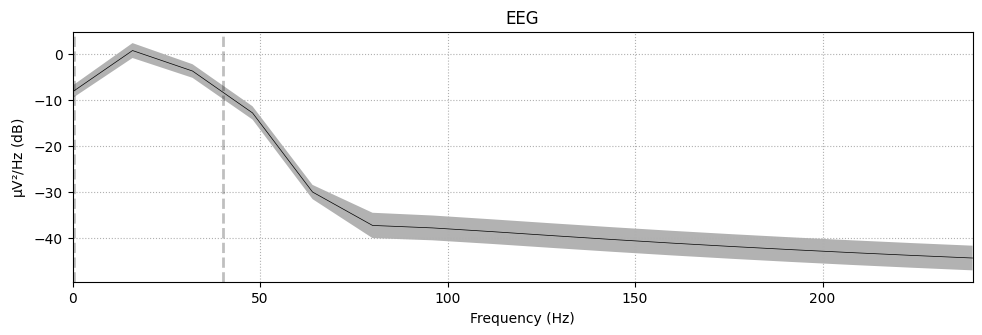

In [20]:
# Notch filter is not needed sometimes
filtered_raw.compute_psd(fmax=250).plot(average=True, picks="data", exclude="bads")





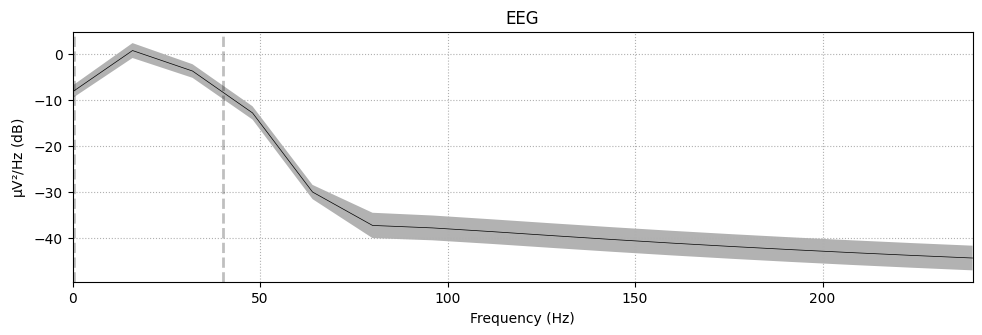

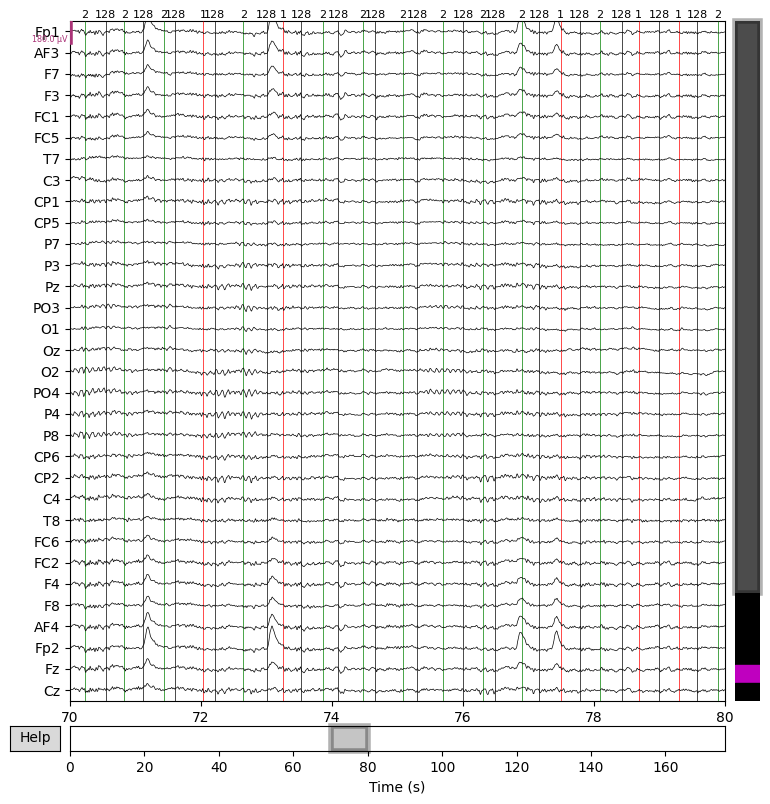

In [21]:
# PLOT

fig = filtered_raw.plot(events=events,
          start=70,
          duration=10, 
          n_channels=32,
          event_color={1: "r", 2: "g", 4: "b", 32: "m", 64: "y", 99: "k",128: "k",129: "k"},
          clipping=None, 
          scalings=dict(eeg=scaling)
         )


# Epoch

In [22]:
epochs = mne.Epochs(filtered_raw, events, tmin=-0.1, tmax=0.4, event_id=event_dict, preload= True)

Not setting metadata
271 matching events found
Setting baseline interval to [-0.10009765625, 0.0] sec
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 271 events and 2049 original time points ...
0 bad epochs dropped


# ICA

In [23]:
# Remove artifacts
# You can use ICA or other artifact removal techniques here
# Example using ICA
#ica = mne.preprocessing.ICA(n_components=20, random_state=100, max_iter=800)
ica = mne.preprocessing.ICA(random_state=100, max_iter=800)
ica.fit(epochs) # Not setting the picks = [ch_names]

#ica.exclude = [0, 1]  # indices of components to exclude
#ica.apply(raw)


Fitting ICA to data using 32 channels (please be patient, this may take a while)


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/2501415319.py:6: RuntimeWarning: The epochs you passed to ICA.fit() were baseline-corrected. However, we suggest to fit ICA only on data that has been high-pass filtered, but NOT baseline-corrected.
  ica.fit(epochs) # Not setting the picks = [ch_names]


Selecting by non-zero PCA components: 32 components
Fitting ICA took 29.9s.


Method,fastica
Fit,58 iterations on epochs (555279 samples)
ICA components,32
Available PCA components,32
Channel types,eeg
ICA components marked for exclusion,—


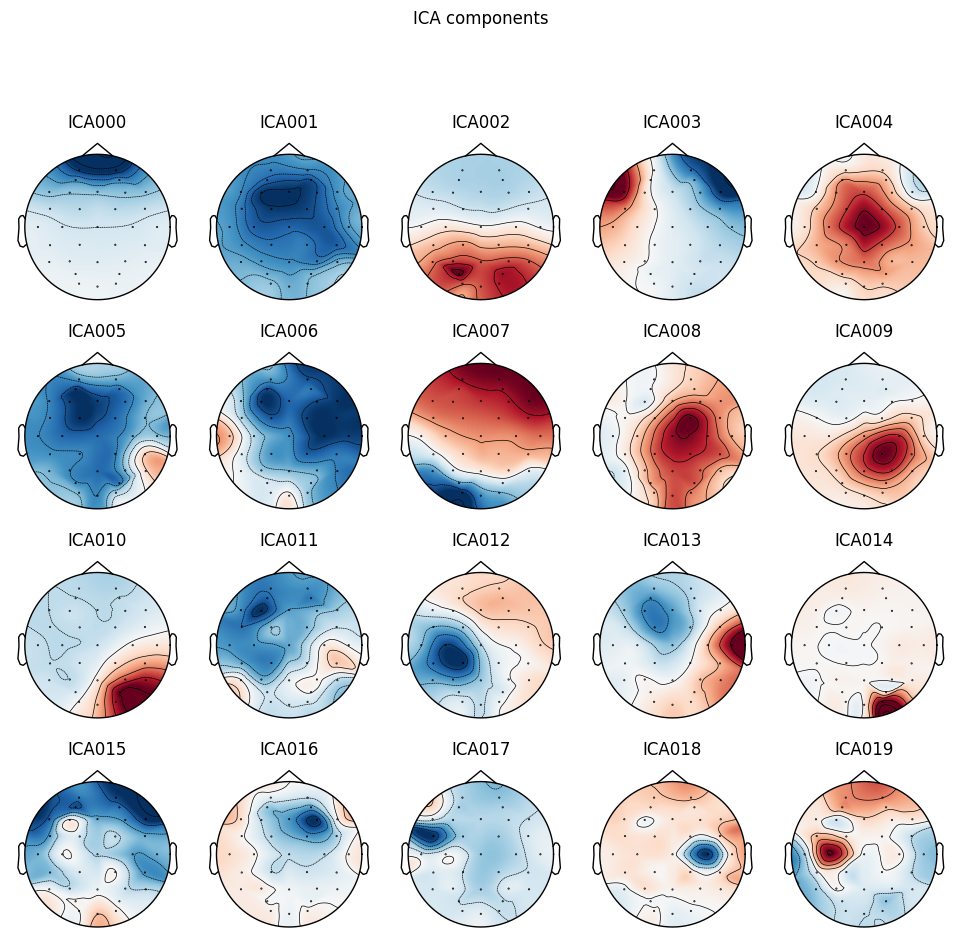

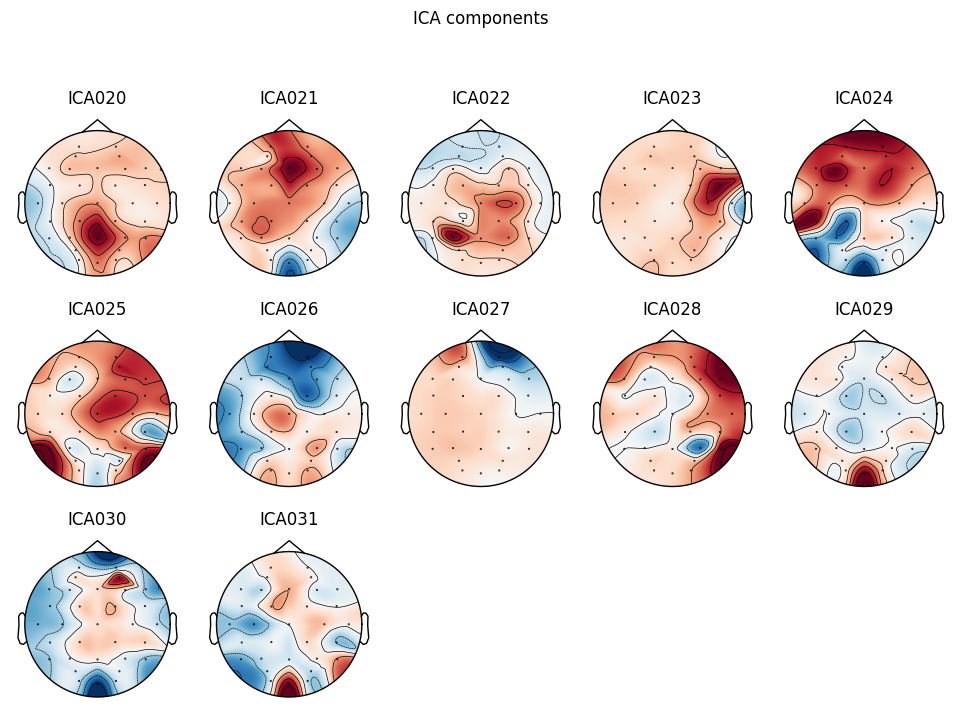

[<MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x731.5 with 12 Axes>]

In [24]:
ica.plot_components()

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
88 matching events found
No baseline correction applied
0 projection items activated


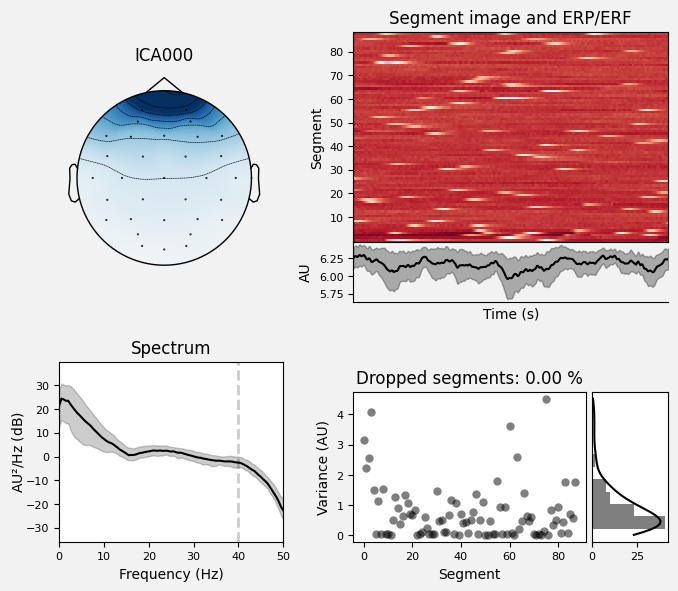

[<Figure size 700x600 with 6 Axes>]

In [25]:
# Excluding eye blinking
ica.exclude = [0]  # details on how we picked these are omitted here
ica.plot_properties(raw, picks=ica.exclude)



In [26]:
builtin_montages = mne.channels.get_builtin_montages(descriptions=True)
for montage_name, montage_description in builtin_montages:
    print(f'{montage_name}: {montage_description}')

standard_1005: Electrodes are named and positioned according to the international 10-05 system (343+3 locations)
standard_1020: Electrodes are named and positioned according to the international 10-20 system (94+3 locations)
standard_alphabetic: Electrodes are named with LETTER-NUMBER combinations (A1, B2, F4, …) (65+3 locations)
standard_postfixed: Electrodes are named according to the international 10-20 system using postfixes for intermediate positions (100+3 locations)
standard_prefixed: Electrodes are named according to the international 10-20 system using prefixes for intermediate positions (74+3 locations)
standard_primed: Electrodes are named according to the international 10-20 system using prime marks (' and '') for intermediate positions (100+3 locations)
biosemi16: BioSemi cap with 16 electrodes (16+3 locations)
biosemi32: BioSemi cap with 32 electrodes (32+3 locations)
biosemi64: BioSemi cap with 64 electrodes (64+3 locations)
biosemi128: BioSemi cap with 128 electrodes (1

Applying ICA to Raw instance
    Transforming to ICA space (32 components)
    Zeroing out 1 ICA component
    Projecting back using 32 PCA components


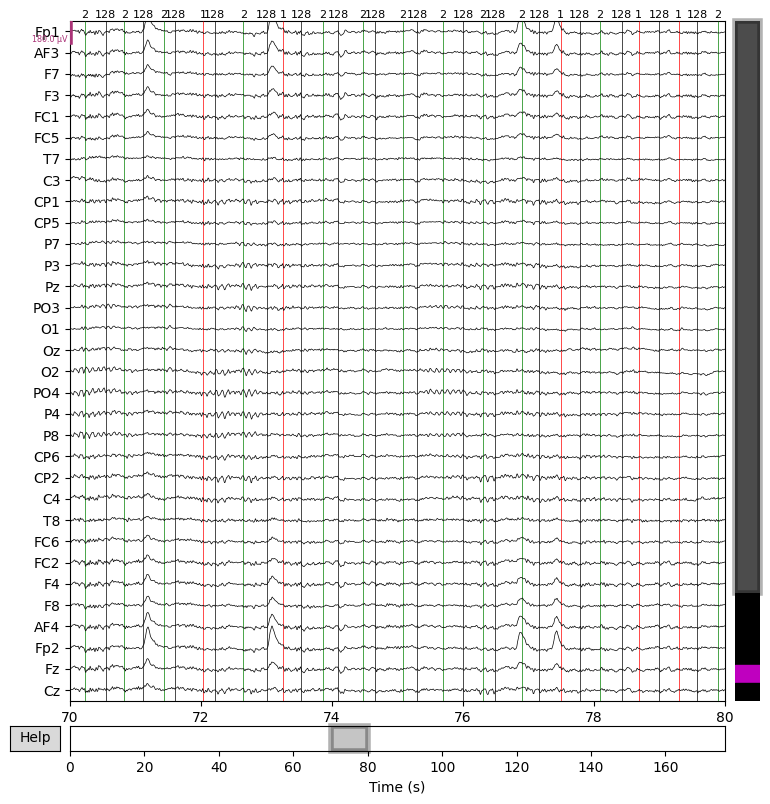

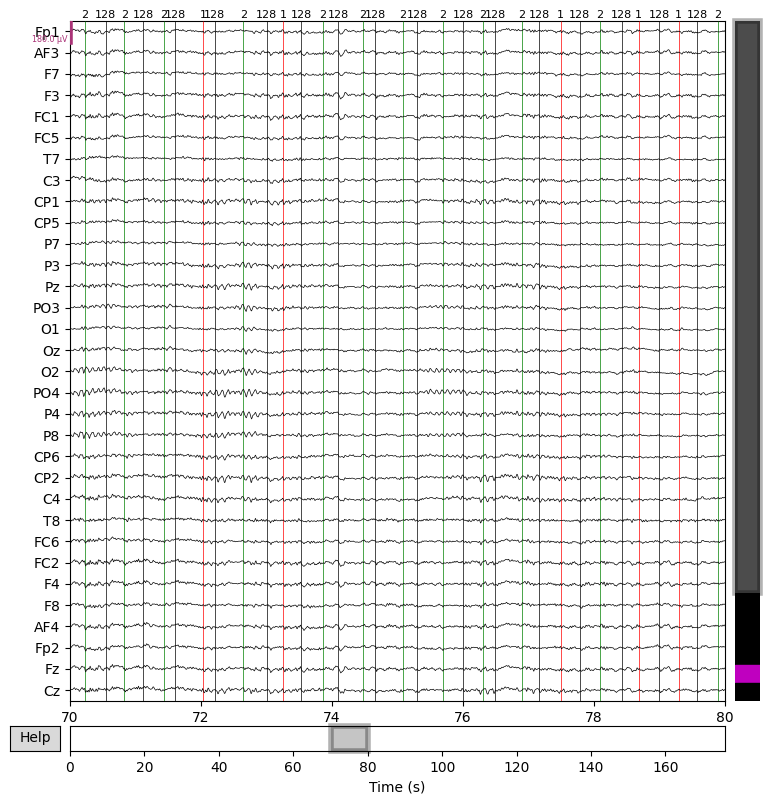

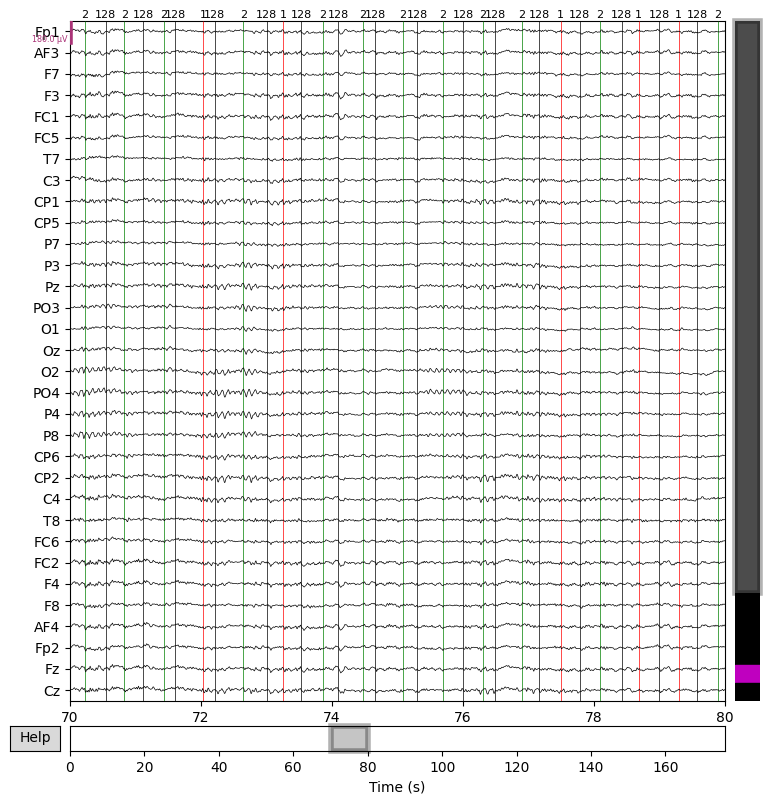

In [27]:
# Make a copy of the original data and apply non-blinking ICA
orig_data = filtered_raw.copy()  #John??? Why do they both have not eye blinking components
filtered_raw.load_data()
ica_filtered_raw = ica.apply(filtered_raw)

orig_data.plot(events=events,
          start=70,
          duration=10, 
          n_channels=32,
          event_color={1: "r", 2: "g", 4: "b", 32: "m", 64: "y", 99: "k",128: "k",129: "k"},
          clipping=None, 
          scalings=dict(eeg=scaling)
         )
ica_filtered_raw.plot(events=events,
          start=70,
          duration=10, 
          n_channels=32,
          event_color={1: "r", 2: "g", 4: "b", 32: "m", 64: "y", 99: "k",128: "k",129: "k"},
          clipping=None, 
          scalings=dict(eeg=scaling)
         )


# Autoreject
https://autoreject.github.io/stable/index.html
https://autoreject.github.io/stable/auto_examples/plot_autoreject_workflow.html
https://autoreject.github.io/stable/generated/autoreject.AutoReject.html#autoreject.AutoReject.fit

In [28]:
epochs = mne.Epochs(ica_filtered_raw, events, tmin=-0.1, tmax=0.4, event_id=event_dict, preload= True)

ar = autoreject.AutoReject(n_interpolate=[1, 2, 3, 4], random_state=11,
                           n_jobs=1, verbose=True)

# fit and transform returns epochs_clean and reject_log
ar.fit(epochs)  # fit on a few epochs to save time
epochs_clean, reject_log = ar.transform(epochs, return_log=True)  

Not setting metadata
271 matching events found
Setting baseline interval to [-0.10009765625, 0.0] sec
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 271 events and 2049 original time points ...
0 bad epochs dropped
Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/32 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/32 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/271 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/4 [00:00<?,       ?it/s]

...

  0%|          | Repairing epochs : 0/271 [00:00<?,       ?it/s]

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=0.70 and n_interpolate=2


  0%|          | Repairing epochs : 0/271 [00:00<?,       ?it/s]

Dropped 3 epochs: 144, 204, 257


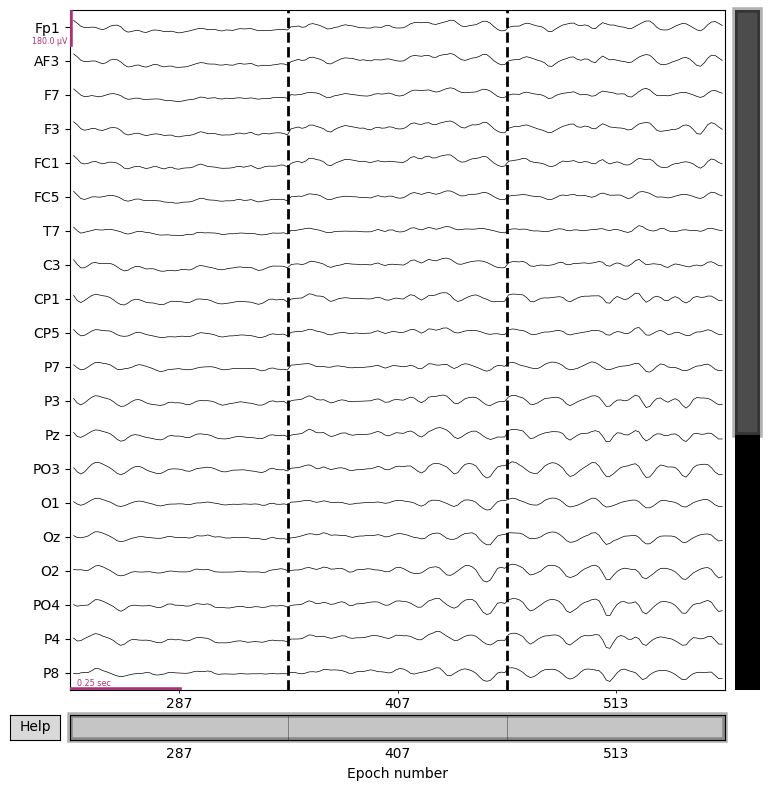

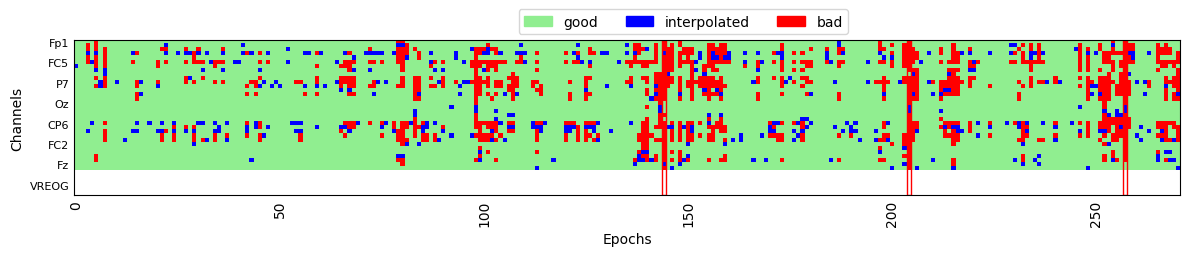

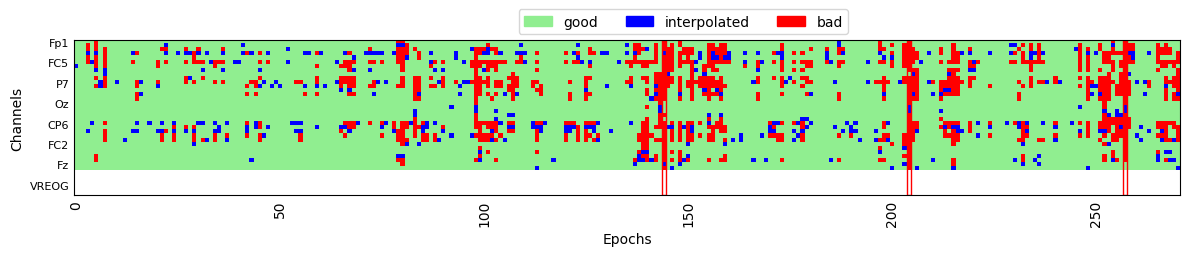

In [29]:
# plotting rejected epochs
bad_fig = epochs[reject_log.bad_epochs].plot(scalings=dict(eeg=scaling))
reject_log.plot('horizontal')

Fitting ICA to data using 32 channels (please be patient, this may take a while)


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/3318295028.py:3: RuntimeWarning: The epochs you passed to ICA.fit() were baseline-corrected. However, we suggest to fit ICA only on data that has been high-pass filtered, but NOT baseline-corrected.
  ica.fit(epochs[~reject_log.bad_epochs])


Selecting by non-zero PCA components: 31 components
Fitting ICA took 42.5s.


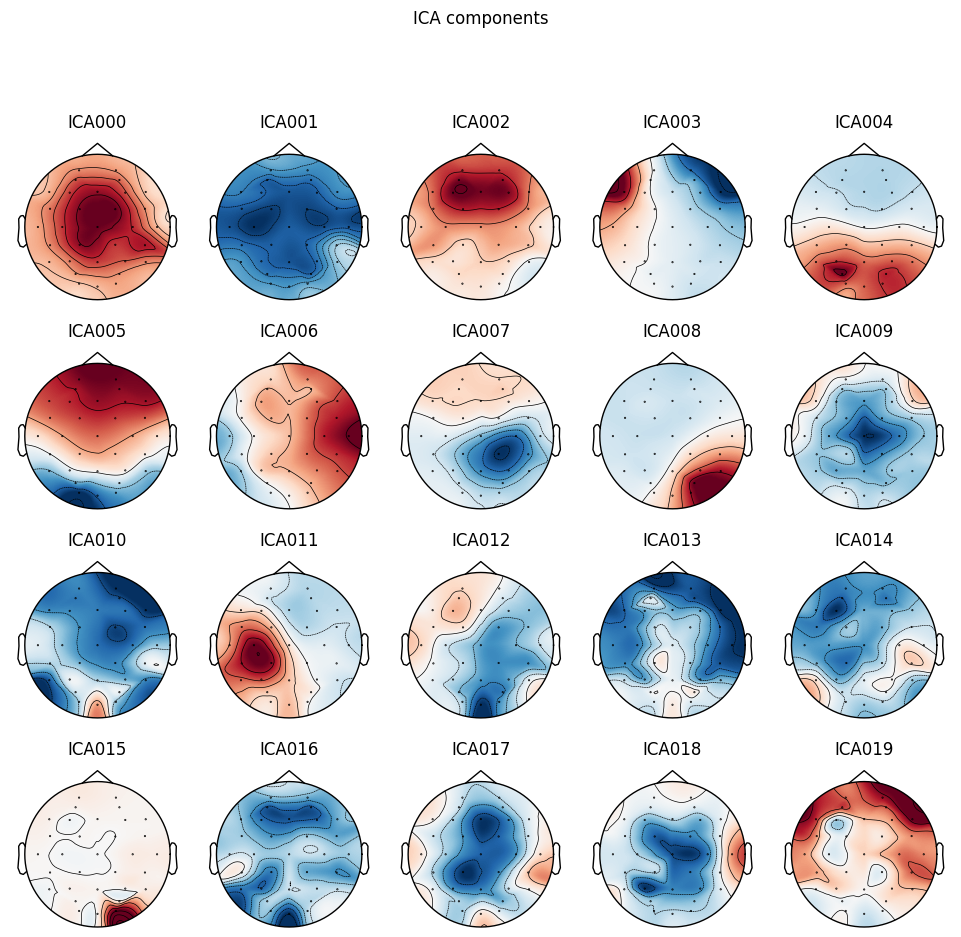

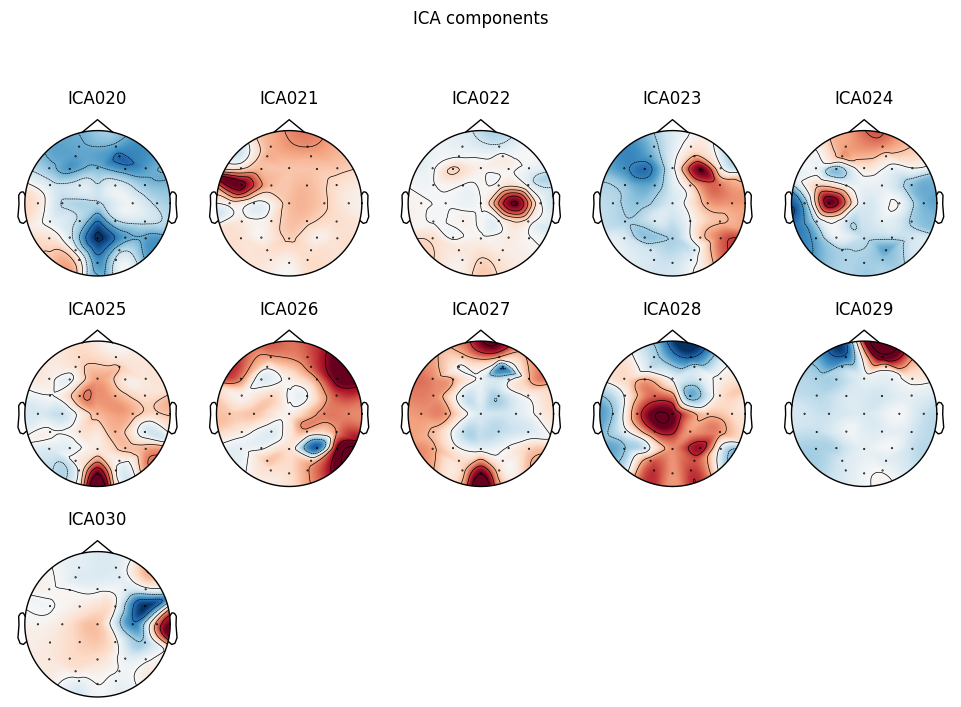

[<MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x731.5 with 11 Axes>]

In [30]:
# compute ICA againg without the reject epochs
ica = mne.preprocessing.ICA(random_state=99)
ica.fit(epochs[~reject_log.bad_epochs])


ica.plot_components()

# Analysis

In [31]:

#conds_we_care_about = ["tone1", "tone2"]
#epochs.equalize_event_counts(conds_we_care_about)  # this operates in-place
tone1_epochs = epochs_clean["tone1"]
tone2_epochs = epochs_clean["tone2"]


## Cz

Not setting metadata
44 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/3171241796.py:3: RuntimeWarning: Only one channel in group "Cz"; cannot combine by method "mean".
  epochs_clean['tone1'].plot_image(picks='Cz', combine='mean')
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/3171241796.py:3: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  epochs_clean['tone1'].plot_image(picks='Cz', combine='mean')


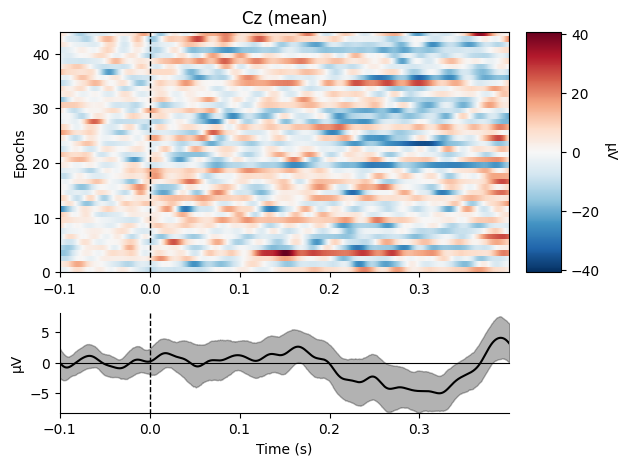

[<Figure size 640x480 with 3 Axes>]

In [59]:
oddball = epochs_clean['tone1'].average()#.detrend()
#epochs['tone1'].plot_image(picks='Cz', combine='mean')
epochs_clean['tone1'].plot_image(picks='Cz', combine='mean')


Not setting metadata
224 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/826723129.py:3: RuntimeWarning: Only one channel in group "Cz"; cannot combine by method "mean".
  epochs_clean['tone2'].plot_image(picks='Cz', combine='mean')
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/826723129.py:3: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  epochs_clean['tone2'].plot_image(picks='Cz', combine='mean')


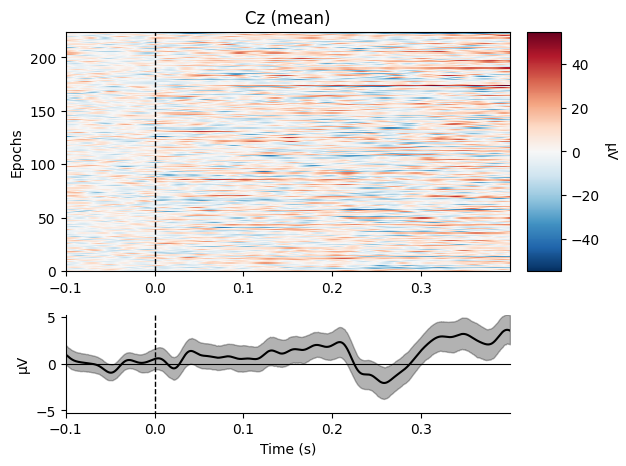

[<Figure size 640x480 with 3 Axes>]

In [58]:
standard = epochs_clean['tone2'].average()#.detrend()
#epochs['tone2'].plot_image(picks='Cz', combine='mean')
epochs_clean['tone2'].plot_image(picks='Cz', combine='mean')


## T7

Not setting metadata
44 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/3629382947.py:1: RuntimeWarning: Only one channel in group "T7"; cannot combine by method "mean".
  epochs_clean['tone1'].plot_image(picks='T7', combine='mean')
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/3629382947.py:1: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  epochs_clean['tone1'].plot_image(picks='T7', combine='mean')


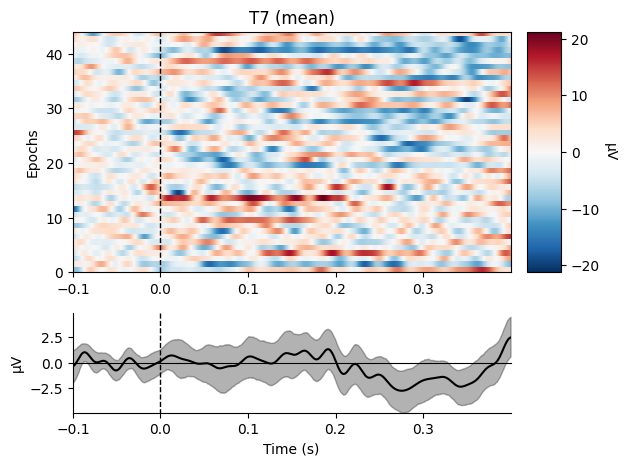

[<Figure size 640x480 with 3 Axes>]

In [67]:
epochs_clean['tone1'].plot_image(picks='T7', combine='mean')


Not setting metadata
224 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/535216254.py:1: RuntimeWarning: Only one channel in group "T7"; cannot combine by method "mean".
  epochs_clean['tone2'].plot_image(picks='T7', combine='mean')
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/535216254.py:1: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  epochs_clean['tone2'].plot_image(picks='T7', combine='mean')


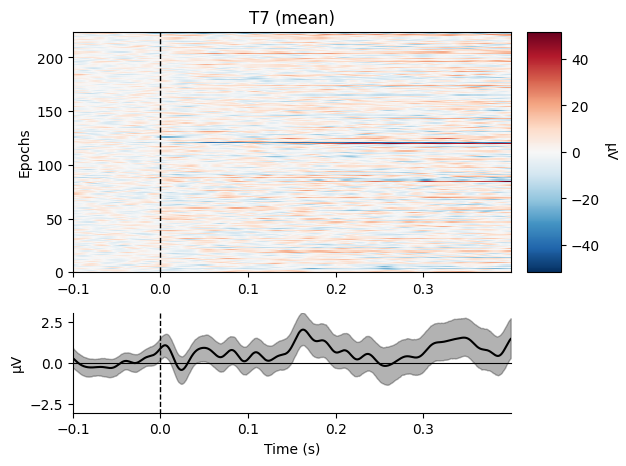

[<Figure size 640x480 with 3 Axes>]

In [68]:
epochs_clean['tone2'].plot_image(picks='T7', combine='mean')


## T8

Not setting metadata
44 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/2137560389.py:1: RuntimeWarning: Only one channel in group "T8"; cannot combine by method "mean".
  epochs_clean['tone1'].plot_image(picks='T8', combine='mean')
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/2137560389.py:1: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  epochs_clean['tone1'].plot_image(picks='T8', combine='mean')


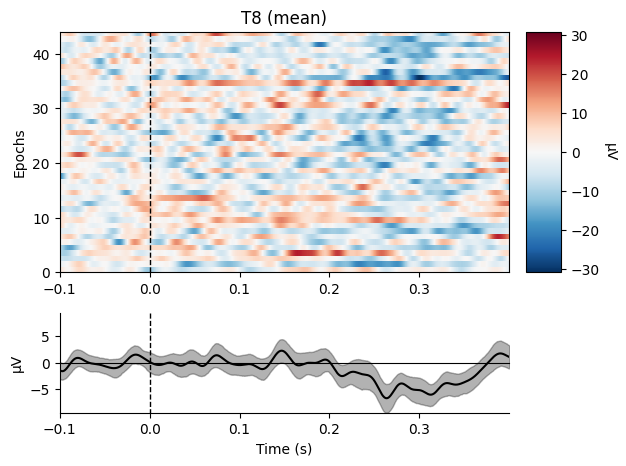

[<Figure size 640x480 with 3 Axes>]

In [66]:
epochs_clean['tone1'].plot_image(picks='T8', combine='mean')


Not setting metadata
224 matching events found
No baseline correction applied
0 projection items activated


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/241285536.py:1: RuntimeWarning: Only one channel in group "T8"; cannot combine by method "mean".
  epochs_clean['tone2'].plot_image(picks='T8', combine='mean')


combining channels using "mean"


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/241285536.py:1: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  epochs_clean['tone2'].plot_image(picks='T8', combine='mean')


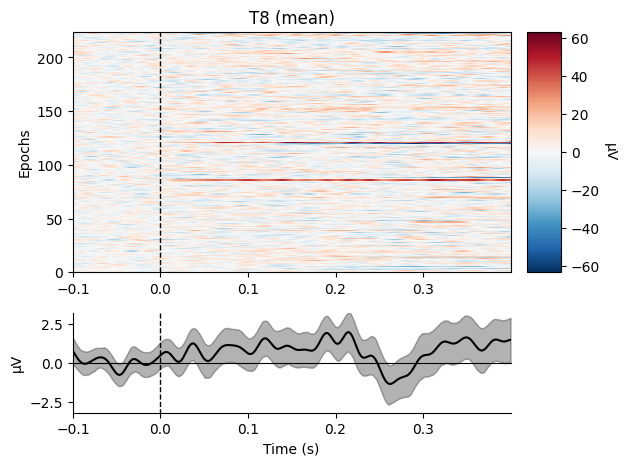

[<Figure size 640x480 with 3 Axes>]

In [65]:
epochs_clean['tone2'].plot_image(picks='T8', combine='mean')


## C3

Not setting metadata
44 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/3108134703.py:1: RuntimeWarning: Only one channel in group "C3"; cannot combine by method "mean".
  epochs_clean['tone1'].plot_image(picks='C3', combine='mean')
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/3108134703.py:1: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  epochs_clean['tone1'].plot_image(picks='C3', combine='mean')


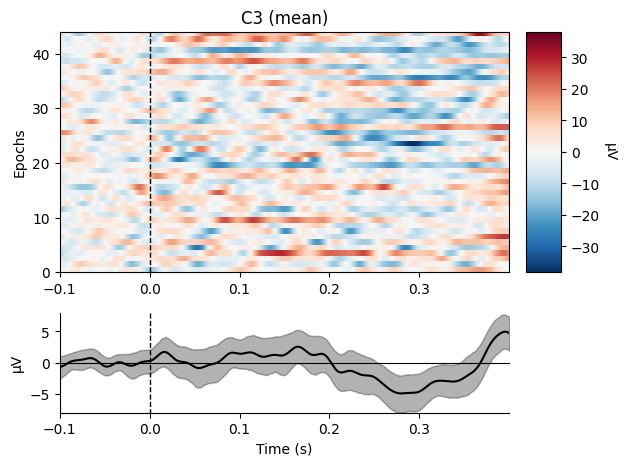

[<Figure size 640x480 with 3 Axes>]

In [69]:
epochs_clean['tone1'].plot_image(picks='C3', combine='mean')


Not setting metadata
224 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/1204035682.py:1: RuntimeWarning: Only one channel in group "C3"; cannot combine by method "mean".
  epochs_clean['tone2'].plot_image(picks='C3', combine='mean')
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/1204035682.py:1: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  epochs_clean['tone2'].plot_image(picks='C3', combine='mean')


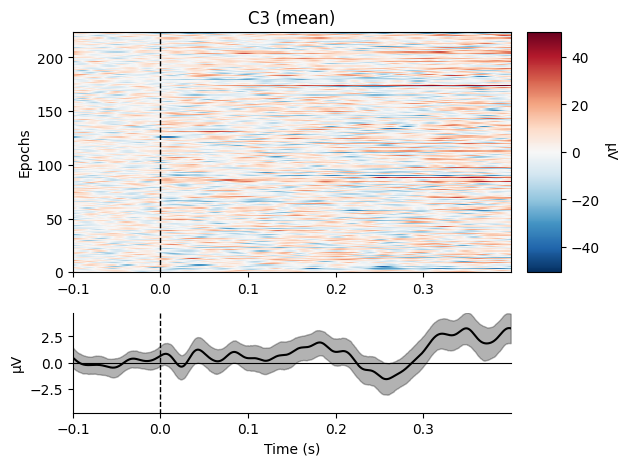

[<Figure size 640x480 with 3 Axes>]

In [70]:
epochs_clean['tone2'].plot_image(picks='C3', combine='mean')

## C4

Not setting metadata
44 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/2311263333.py:1: RuntimeWarning: Only one channel in group "C4"; cannot combine by method "mean".
  epochs_clean['tone1'].plot_image(picks='C4', combine='mean')
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/2311263333.py:1: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  epochs_clean['tone1'].plot_image(picks='C4', combine='mean')


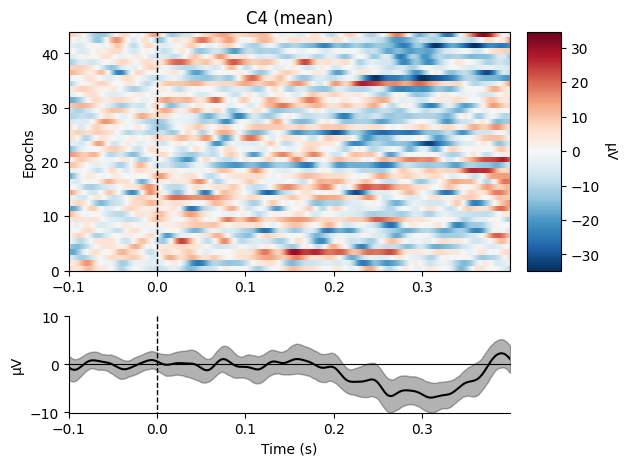

[<Figure size 640x480 with 3 Axes>]

In [71]:
epochs_clean['tone1'].plot_image(picks='C4', combine='mean')

Not setting metadata
224 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/4031033364.py:1: RuntimeWarning: Only one channel in group "C4"; cannot combine by method "mean".
  epochs_clean['tone2'].plot_image(picks='C4', combine='mean')
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/4031033364.py:1: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  epochs_clean['tone2'].plot_image(picks='C4', combine='mean')


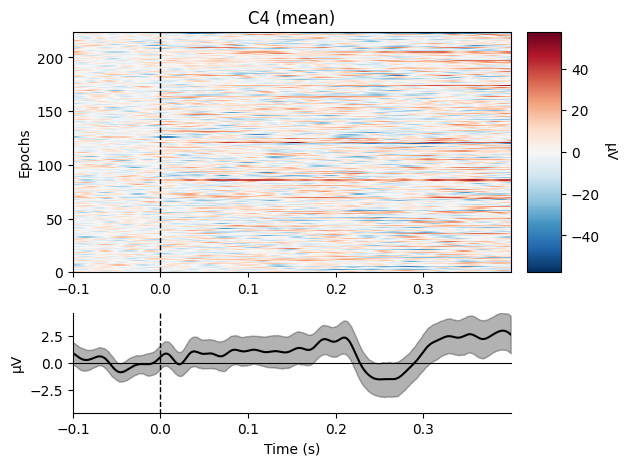

[<Figure size 640x480 with 3 Axes>]

In [72]:
epochs_clean['tone2'].plot_image(picks='C4', combine='mean')


## Fz

Not setting metadata
44 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/72904905.py:1: RuntimeWarning: Only one channel in group "Fz"; cannot combine by method "mean".
  epochs_clean['tone1'].plot_image(picks='Fz', combine='mean')
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/72904905.py:1: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  epochs_clean['tone1'].plot_image(picks='Fz', combine='mean')


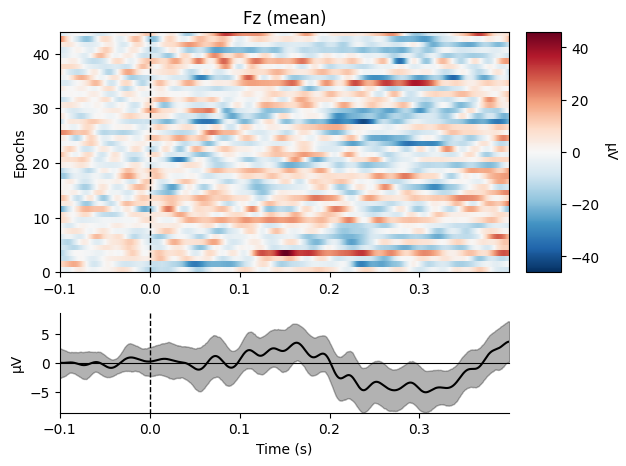

[<Figure size 640x480 with 3 Axes>]

In [64]:
epochs_clean['tone1'].plot_image(picks='Fz', combine='mean')


Not setting metadata
224 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/1428447345.py:1: RuntimeWarning: Only one channel in group "Fz"; cannot combine by method "mean".
  epochs_clean['tone2'].plot_image(picks='Fz', combine='mean')
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/1428447345.py:1: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  epochs_clean['tone2'].plot_image(picks='Fz', combine='mean')


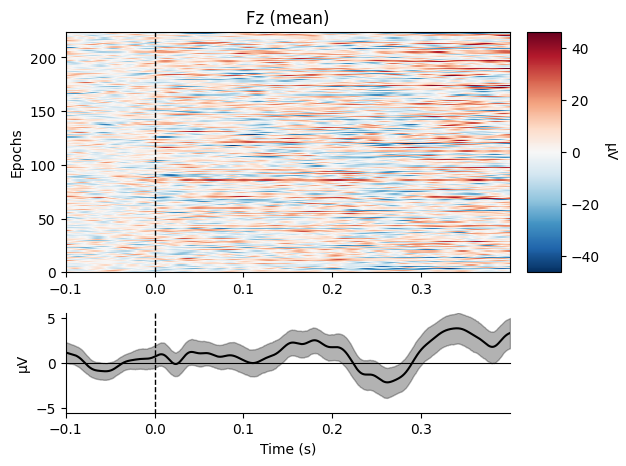

[<Figure size 640x480 with 3 Axes>]

In [63]:
epochs_clean['tone2'].plot_image(picks='Fz', combine='mean')


combining channels using "gfp"
combining channels using "gfp"


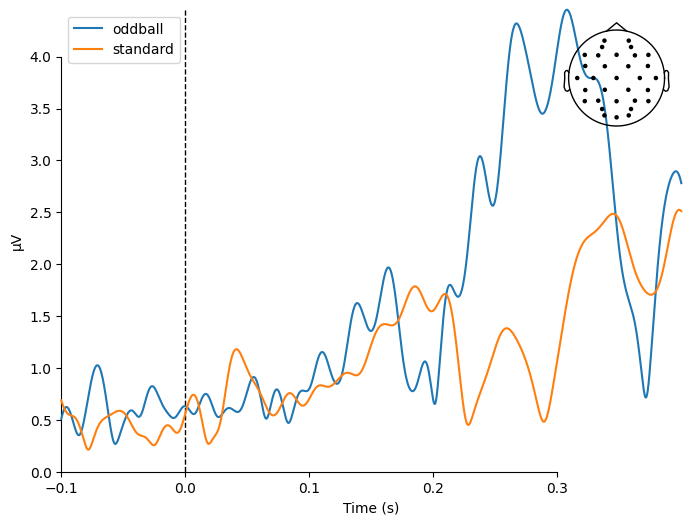

[<Figure size 800x600 with 2 Axes>]

In [51]:
# Clean epochs only
mne.viz.plot_compare_evokeds(
    dict(oddball=oddball, standard=standard),
    legend="upper left",
    show_sensors="upper right",
)


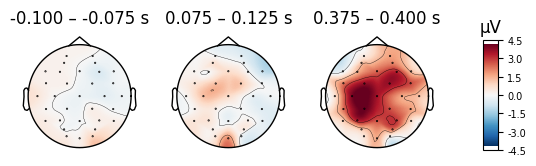

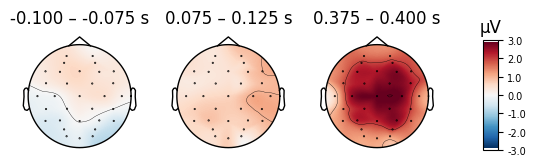

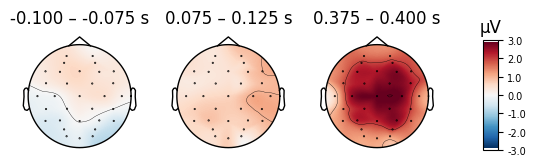

In [62]:
oddball.plot_topomap(times=[-0.1, 0.1, 0.4], average=0.05)
standard.plot_topomap(times=[-0.1, 0.1, 0.4], average=0.05);

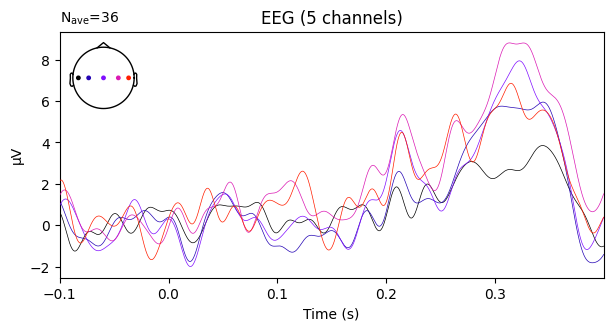

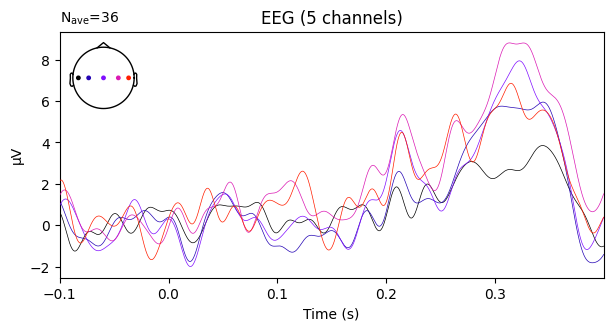

In [35]:
evoked_diff = mne.combine_evoked([standard, oddball], weights=[1, -1])
evoked_diff.plot(picks=["T7", "C3","Cz","C4","T8"])



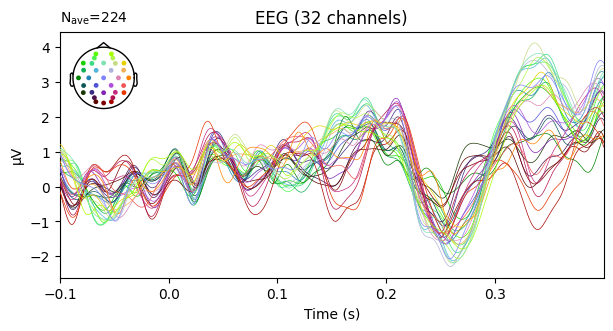

/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/1080916503.py:2: FutureWarning: The "vmin" and "vmax" parameters are deprecated and will be removed in version 1.3. Use the "vlim" parameter instead.
  fig = standard.plot_topomap(times = [0.3] , average=0.05, vmin = -5, vmax = 5)


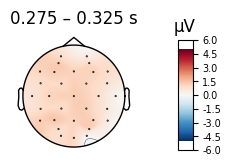

Text(0.5, 0.98, 'Auditory response - Standard')

In [36]:
standard.plot()
fig = standard.plot_topomap(times = [0.3] , average=0.05, vmin = -5, vmax = 5)
fig.suptitle("Auditory response - Standard")

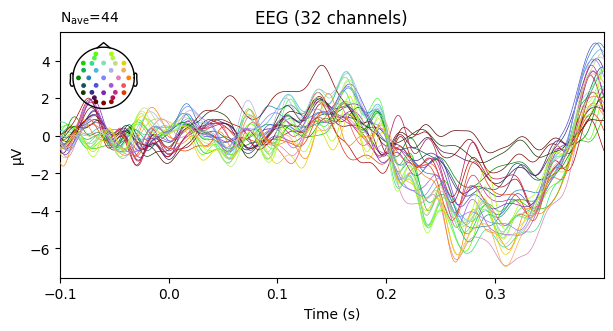

/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_15212/2181486097.py:2: FutureWarning: The "vmin" and "vmax" parameters are deprecated and will be removed in version 1.3. Use the "vlim" parameter instead.
  fig = oddball.plot_topomap(times = [0.3] , average=0.05, vmin = -5, vmax = 5)


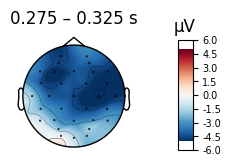

Text(0.5, 0.98, 'Auditory response - oddball')

In [37]:
oddball.plot()
fig = oddball.plot_topomap(times = [0.3] , average=0.05, vmin = -5, vmax = 5)
fig.suptitle("Auditory response - oddball")

# Plot oddball and standard on top of each other with different colour code for each.


In [40]:
print(epochs_clean.info)

<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, AF3, F7, F3, FC1, FC5, T7, C3, CP1, CP5, P7, P3, Pz, PO3, ...
 chs: 32 EEG, 4 EOG, 1 ECG, 1 Stimulus
 custom_ref_applied: True
 dig: 35 items (3 Cardinal, 32 EEG)
 highpass: 0.5 Hz
 lowpass: 40.0 Hz
 meas_date: 2024-02-16 11:07:02 UTC
 nchan: 38
 projs: []
 sfreq: 4096.0 Hz
>


In [41]:
print(epochs_clean.info['dig'])

[<DigPoint |        LPA : (-86.1, -0.0, 0.0) mm     : head frame>, <DigPoint |     Nasion : (0.0, 86.1, 0.0) mm       : head frame>, <DigPoint |        RPA : (86.1, 0.0, 0.0) mm       : head frame>, <DigPoint |     EEG #1 : (-29.3, 90.3, 36.8) mm    : head frame>, <DigPoint |     EEG #2 : (-38.6, 82.8, 66.3) mm    : head frame>, <DigPoint |     EEG #3 : (-76.8, 55.8, 36.8) mm    : head frame>, <DigPoint |     EEG #4 : (-51.8, 63.9, 87.6) mm    : head frame>, <DigPoint |     EEG #5 : (-35.6, 35.6, 120.7) mm   : head frame>, <DigPoint |     EEG #6 : (-84.3, 32.4, 69.5) mm    : head frame>, <DigPoint |     EEG #7 : (-94.9, -0.0, 36.8) mm    : head frame>, <DigPoint |     EEG #8 : (-68.3, -0.0, 106.1) mm   : head frame>, <DigPoint |     EEG #9 : (-35.6, -35.6, 120.7) mm  : head frame>, <DigPoint |    EEG #10 : (-84.3, -32.4, 69.5) mm   : head frame>, <DigPoint |    EEG #11 : (-76.8, -55.8, 36.8) mm   : head frame>, <DigPoint |    EEG #12 : (-51.8, -63.9, 87.6) mm   : head frame>, <DigPoint

In [ ]:
# https://www.youtube.com/watch?v=31N8WHioQ3U

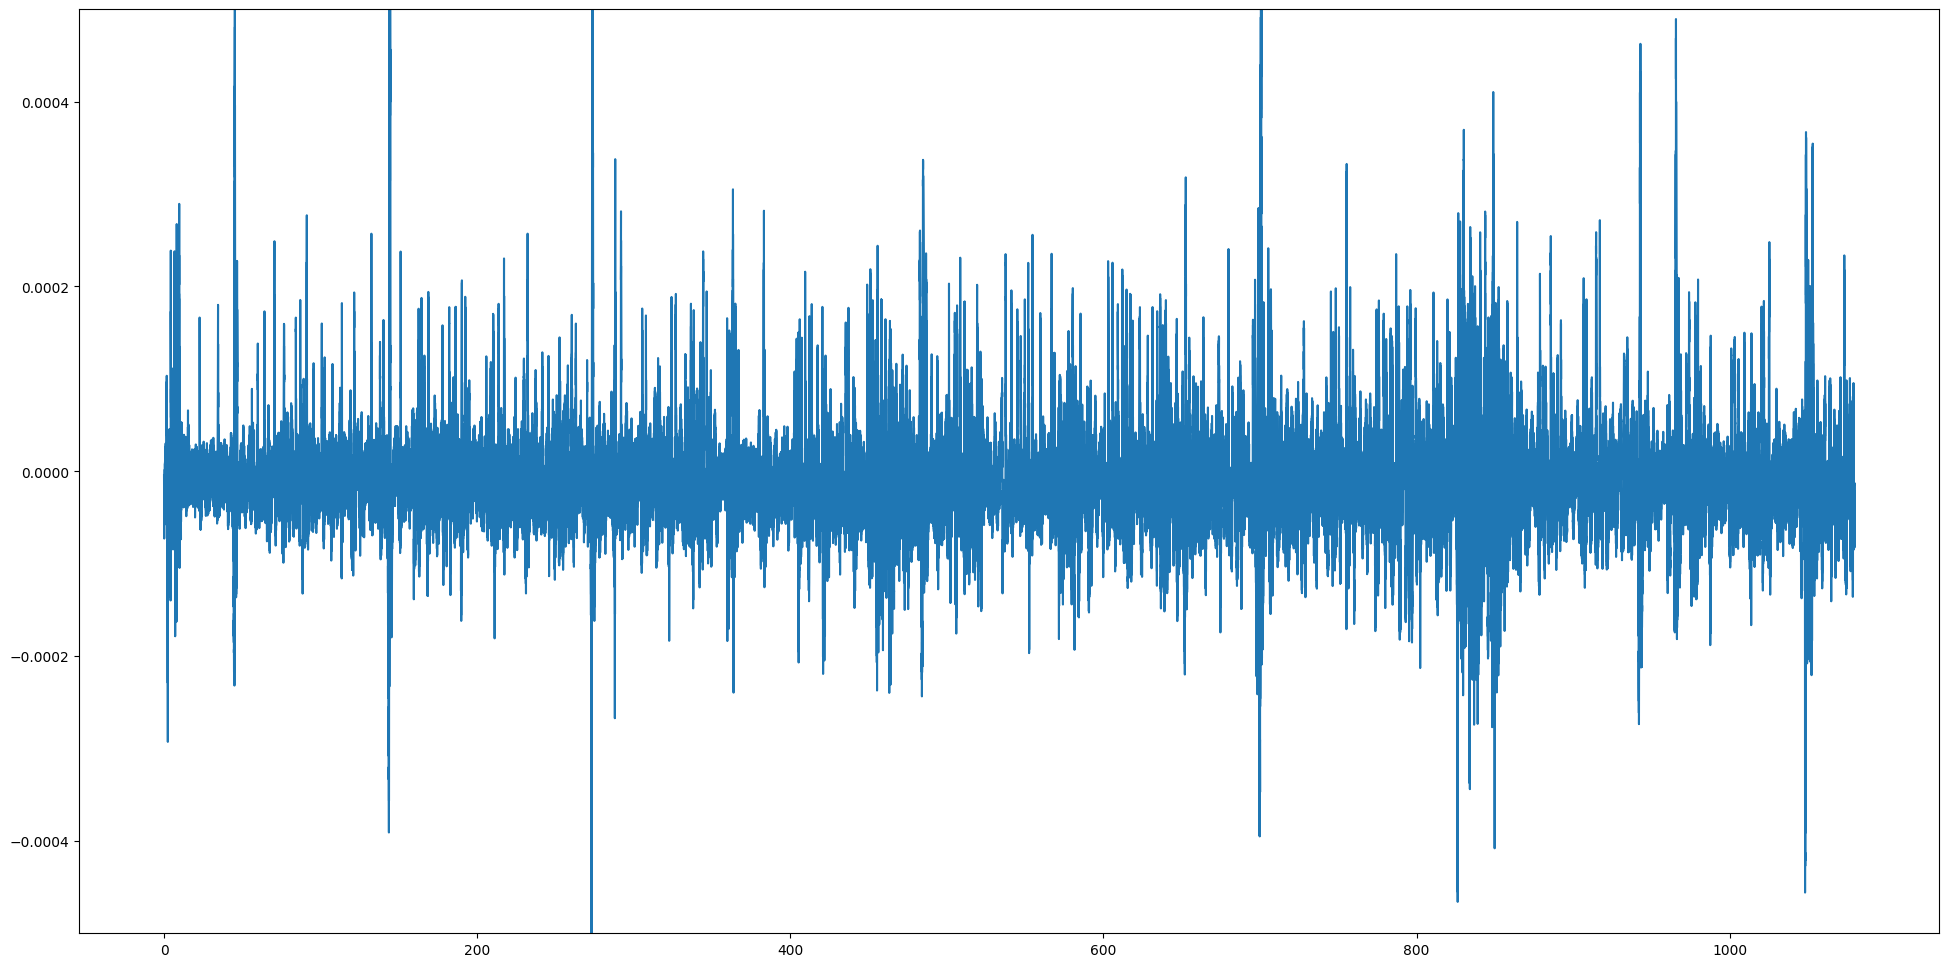

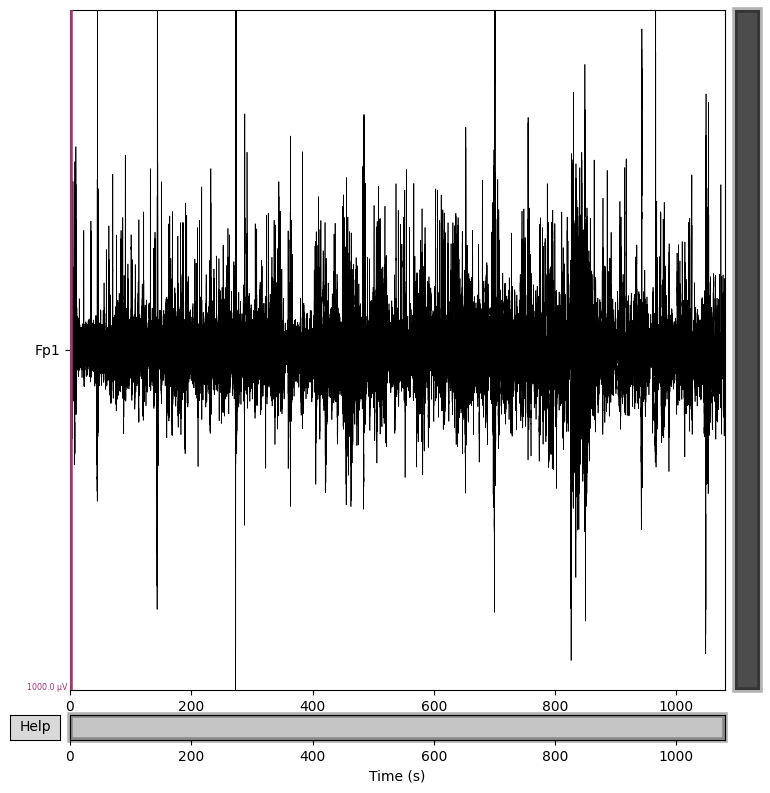

In [61]:
'''
import matplotlib
from matplotlib import pyplot as plt

plt.ion()
picks = 'Fp1'  # which channel to plot
scaling = 5e-4

# make figure sizes the same
fig, ax = plt.subplots(figsize=(24, 12))

# plot with matplotlib
ax.plot(raw.times, raw.get_data(picks=picks).squeeze())
ax.set(ylim=(-scaling, scaling))

# plot with MNE-Python
mne_fig = raw.pick(picks).plot(duration=raw.times[-1], scalings=dict(eeg=scaling))
'''


In [31]:
# No blinking nor saccades after dropping the bad epochs

'''exclude = [0,  # blinks
           2  # saccades
           ]
ica.plot_components(exclude)
ica.exclude = exclude'''

'exclude = [0,  # blinks\n           2  # saccades\n           ]\nica.plot_components(exclude)\nica.exclude = exclude'